In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from datasets import load_dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import TextVectorization, Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.models import Sequential
from collections import Counter

In [2]:
ds = load_dataset("armanc/pubmed-rct20k")
print(ds)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/646 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json: 0.00B [00:00, ?B/s]

train.jsonl:   0%|          | 0.00/40.7M [00:00<?, ?B/s]

...

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/176642 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/29672 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/29578 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 176642
    })
    validation: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 29672
    })
    test: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 29578
    })
})


In [3]:
df_train = pd.DataFrame(ds['train'])
df_train.head()

,abstract_id,label,text,sentence_id
0,24293578,objective,To investigate the efficacy of @ weeks of dail...,0
1,24293578,methods,A total of @ patients with primary knee OA wer...,1
2,24293578,methods,Outcome measures included pain reduction and i...,2
3,24293578,methods,Pain was assessed using the visual analog pain...,3
4,24293578,methods,Secondary outcome measures included the Wester...,4


In [4]:
df_validation = pd.DataFrame(ds['validation'])
df_validation.head()

,abstract_id,label,text,sentence_id
0,24290286,background,IgE sensitization to Aspergillus fumigatus and...,0
1,24290286,background,It is not clear whether these patients would b...,1
2,24290286,objective,We sought to determine whether a @-month cours...,2
3,24290286,methods,Asthmatic patients who were IgE sensitized to ...,3
4,24290286,methods,Primary outcomes were improvement in quality o...,4


In [5]:
df_test = pd.DataFrame(ds['test'])
df_test.head()

,abstract_id,label,text,sentence_id
0,24845963,background,This study analyzed liver function abnormaliti...,0
1,24845963,results,A post hoc analysis was conducted with the use...,1
2,24845963,results,Liver function tests ( LFTs ) were measured at...,2
3,24845963,results,Survival analyses were used to assess the asso...,3
4,24845963,results,The percentage of patients with abnormal LFTs ...,4


In [6]:
label_counts = df_train['label'].value_counts()
label_props = df_train['label'].value_counts(normalize=True) * 100
print(label_counts)
print(label_props.round(2))

label
methods        59281
results        57953
conclusions    27168
background     18402
objective      13838
Name: count, dtype: int64
label
methods        33.56
results        32.81
conclusions    15.38
background     10.42
objective       7.83
Name: proportion, dtype: float64


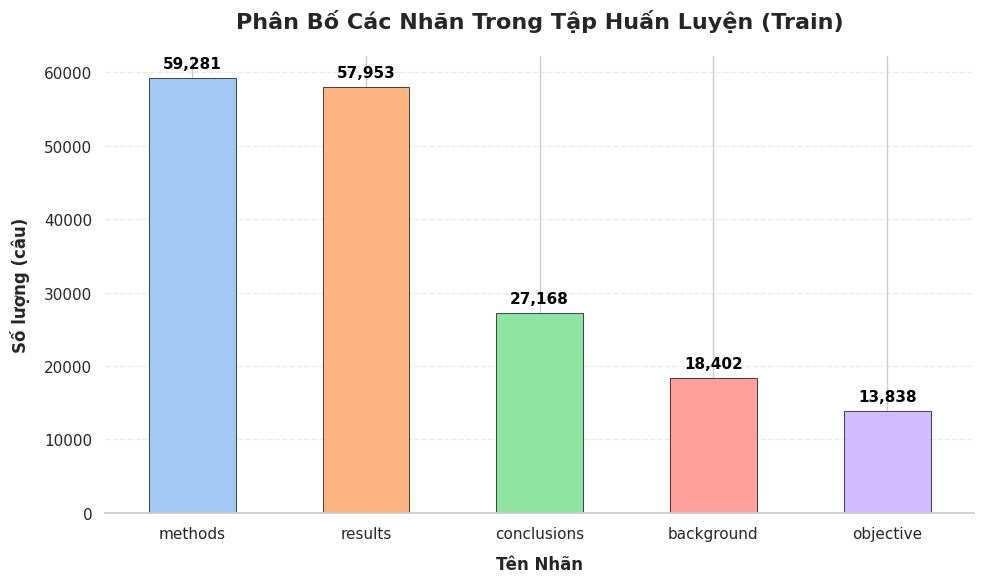

In [8]:
# 1. Cài đặt phong cách hiện đại của Seaborn
sns.set_theme(style="whitegrid")

# 2. Tăng kích thước chiều cao một chút cho thoáng
plt.figure(figsize=(10, 6))

# 3. Tạo bảng màu đẹp mắt (ví dụ: pastel, husl, hoặc blues) thay vì 1 màu
colors = sns.color_palette("pastel", len(label_counts))

# 4. Vẽ biểu đồ (thêm viền đen mỏng cho cột thêm sắc nét)
ax = label_counts.plot(kind='bar', color=colors, edgecolor='black', linewidth=0.5)

# 5. Tùy chỉnh Tiêu đề và Trục với Font chữ to, in đậm
plt.title('Phân Bố Các Nhãn Trong Tập Huấn Luyện (Train)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tên Nhãn', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Số lượng (câu)', fontsize=12, fontweight='bold', labelpad=10)

# 6. Chỉnh góc xoay nhãn (Với 5 nhãn thì để góc 0 độ hoặc 15 độ là dễ đọc nhất)
plt.xticks(rotation=0, fontsize=11, fontweight='500')
plt.yticks(fontsize=11)

# 7. Xóa bỏ đường viền rác ở trên và bên phải (Tối giản hóa)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False) # Có thể tắt luôn viền trái vì đã có lưới ngang

# Làm mờ đường lưới ngang để không tranh giành sự chú ý với cột
plt.grid(axis='y', linestyle='--', alpha=0.4)

# 8. Hiển thị số liệu trên đầu cột (Thêm dấu phẩy ngăn cách hàng nghìn)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', # Định dạng số: 10000 -> 10,000
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=11, color='black', fontweight='bold',
                xytext=(0, 5), textcoords='offset points')

# Đảm bảo bố cục không bị cắt xén
plt.tight_layout()
plt.show()

In [9]:
df_train['sentence_len'] = df_train['text'].apply(lambda x: len(x.split()))
print(f"Câu ngắn nhất: {df_train['sentence_len'].min()} từ")
print(f"Câu dài nhất: {df_train['sentence_len'].max()} từ")
print(f"Độ dài trung bình: {df_train['sentence_len'].mean():.1f} từ")

Câu ngắn nhất: 1 từ
Câu dài nhất: 296 từ
Độ dài trung bình: 26.7 từ


In [10]:
# 1. Tính giá trị trung bình (Mean - μ)
mu = df_train['sentence_len'].mean()

# 2. Tính độ lệch chuẩn (Standard Deviation - σ)
sigma = df_train['sentence_len'].std()

# 3. Tính Max Length theo công thức thống kê
max_len_math = mu + 2 * sigma

# In kết quả ra màn hình
print(f"--- THỐNG KÊ CHI TIẾT TẬP DỮ LIỆU ---")
print(f"Trung bình (μ): {mu:.2f} từ/câu")
print(f"Độ lệch chuẩn (σ): {sigma:.2f} từ")
print(f"-----------------------------------")
print(f"=> Điểm cắt theo công thức (μ + 2σ) = {int(max_len_math)} từ")

--- THỐNG KÊ CHI TIẾT TẬP DỮ LIỆU ---
Trung bình (μ): 26.70 từ/câu
Độ lệch chuẩn (σ): 15.28 từ
-----------------------------------
=> Điểm cắt theo công thức (μ + 2σ) = 57 từ


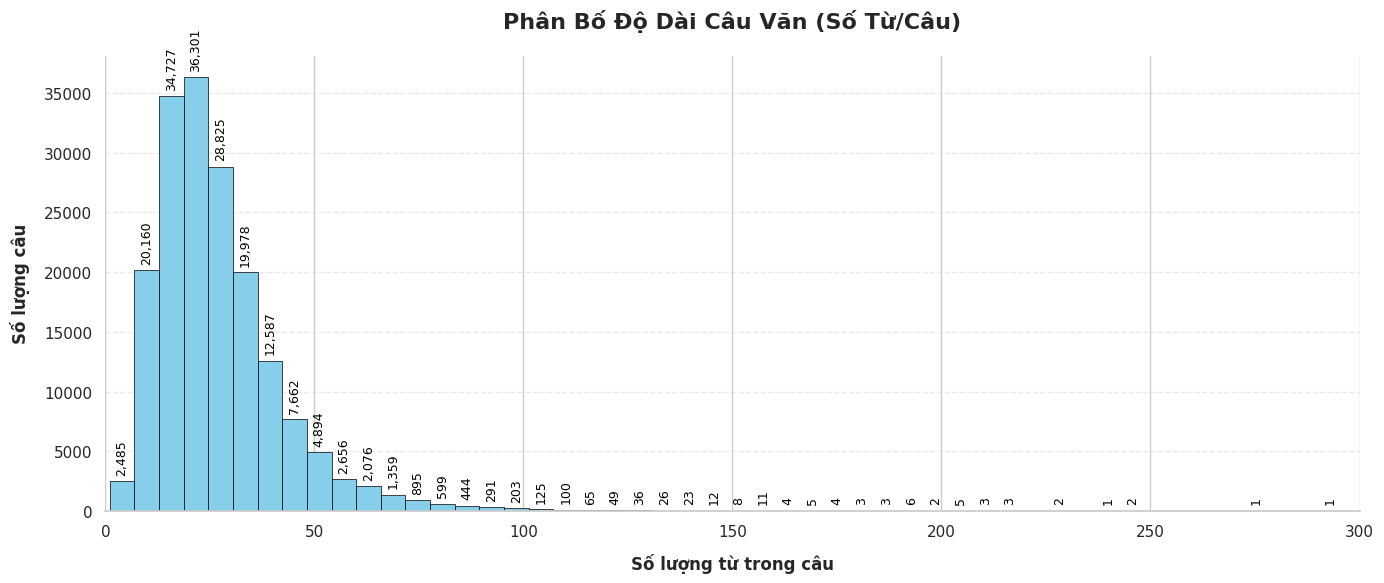

In [12]:
# 1. Cài đặt phong cách hiện đại, nền lưới trắng của Seaborn
sns.set_theme(style="whitegrid")

# 2. Tăng kích thước chiều ngang để 50 cột (bins) không bị ép chật lại với nhau
plt.figure(figsize=(14, 6))

# 3. Vẽ Histogram với màu skyblue, viền đen mỏng tạo độ sắc nét
counts, bins, patches = plt.hist(df_train['sentence_len'], bins=50,
                                 color='skyblue', edgecolor='black', linewidth=0.5)

# 4. Tùy chỉnh Tiêu đề và Trục với Typography chuyên nghiệp
plt.title('Phân Bố Độ Dài Câu Văn (Số Từ/Câu)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Số lượng từ trong câu', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Số lượng câu', fontsize=12, fontweight='bold', labelpad=10)

# Giới hạn vùng hiển thị trục X
plt.xlim(0, 300)

# 5. Xóa bỏ các đường viền thừa (Spines) để tập trung vào dữ liệu
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Làm mờ đường lưới ngang cho tinh tế
plt.grid(axis='y', linestyle='--', alpha=0.4)

# 6. Gắn text trên đỉnh cột cực kỳ thông minh
# Tính toán khoảng đệm (padding) linh hoạt bằng 1.5% chiều cao của cột cao nhất
y_padding = max(counts) * 0.015

for count, patch in zip(counts, patches):
    if count > 0: # Tránh ghi đè số 0 làm rối biểu đồ
        plt.text(x=patch.get_x() + patch.get_width() / 2,
                 y=patch.get_height() + y_padding,
                 s=f'{int(count):,}', # Định dạng hàng nghìn: 10000 -> 10,000
                 ha='center', va='bottom',
                 fontsize=9, color='black', rotation=90) # Giữ xoay 90 độ để các số không đâm vào nhau

# Đảm bảo bố cục hoàn hảo
plt.tight_layout()
plt.show()

In [13]:
p90 = df_train['sentence_len'].quantile(0.90)
p95 = df_train['sentence_len'].quantile(0.95)
p99 = df_train['sentence_len'].quantile(0.99)

print(f"90% số câu trong dữ liệu dài dưới {p90} từ.")
print(f"95% số câu trong dữ liệu dài dưới {p95} từ.")
print(f"99% số câu trong dữ liệu dài dưới {p99} từ.")

90% số câu trong dữ liệu dài dưới 45.0 từ.
95% số câu trong dữ liệu dài dưới 55.0 từ.
99% số câu trong dữ liệu dài dưới 80.0 từ.


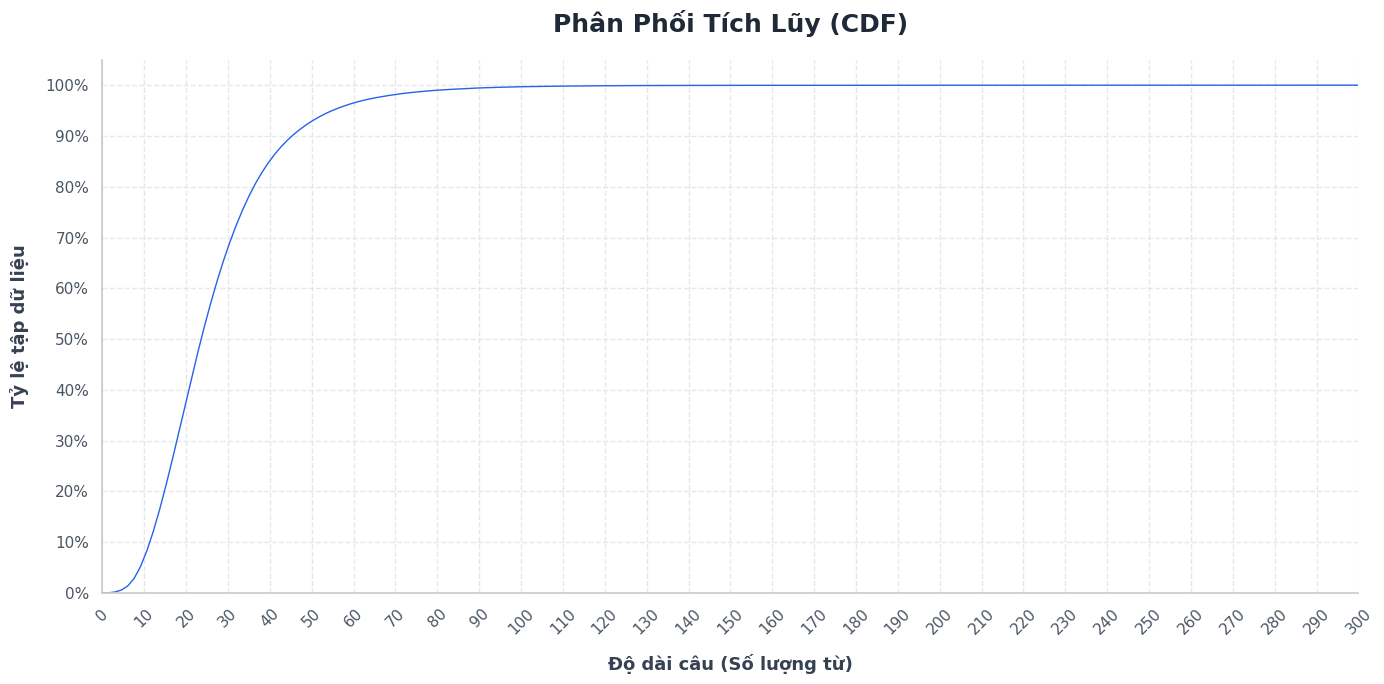

In [20]:
# Tính toán các mốc phân vị (Giữ nguyên gốc)
# p90 = df_train['sentence_len'].quantile(0.90)
# p95 = df_train['sentence_len'].quantile(0.95)
# p99 = df_train['sentence_len'].quantile(0.99)

# 1. Cài đặt phong cách hiện đại
sns.set_theme(style="whitegrid", rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": "#E5E7EB",
    "grid.linestyle": "--"
})
plt.figure(figsize=(14, 7)) # Nới rộng khung hình một chút để chứa đủ trục X

# 2. Vẽ biểu đồ tích lũy (dùng kdeplot để đường cong mượt mà)
sns.kdeplot(data=df_train, x='sentence_len', cumulative=True, color='#2563EB', linewidth=1)

# 3. Tùy chỉnh Tiêu đề và Trục
plt.title('Phân Phối Tích Lũy (CDF)', fontsize=18, fontweight='900', pad=20, color='#1F2937')
plt.xlabel('Độ dài câu (Số lượng từ)', fontsize=13, fontweight='bold', labelpad=12, color='#374151')
plt.ylabel('Tỷ lệ tập dữ liệu', fontsize=13, fontweight='bold', labelpad=12, color='#374151')

# 4. Tùy chỉnh trục Y: Từ 0.0 đến 1.0, mỗi nấc nhảy 0.1 (tức 10%)
y_ticks = np.arange(0, 1.1, 0.1)
y_labels = [f"{int(val*100)}%" for val in y_ticks] # Tạo nhãn: '0%', '10%', ...
plt.yticks(y_ticks, y_labels, fontsize=11, color='#4B5563')

# 5. Tùy chỉnh trục X: Từ 0 đến 300, mỗi nấc nhảy 10 từ
x_ticks = np.arange(0, 301, 10)
# Xoay nghiêng 45 độ để các số từ 0, 10, 20... không bị đè lên nhau
plt.xticks(x_ticks, rotation=45, fontsize=11, color='#4B5563')

plt.xlim(0, 300)
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1055/1114443049.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_words, x='Tần suất', y='Từ vựng', palette='viridis')


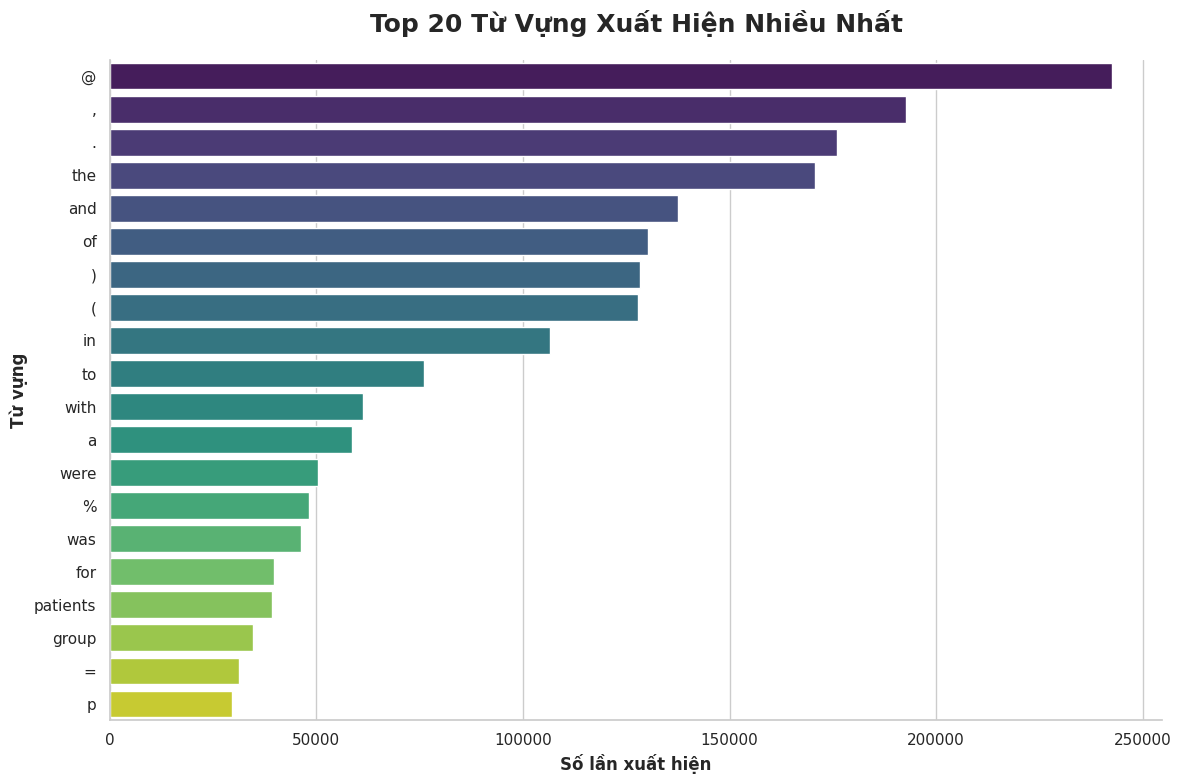

In [21]:
# 1. Gom tất cả các văn bản lại và tách từ (tách theo khoảng trắng)
# Lưu ý: Hàm này đếm thô, TextVectorization của Keras có thể lọc dấu câu kỹ hơn,
# nhưng để EDA (khám phá dữ liệu) thì cách này là đủ tốt.
all_text = " ".join(df_train['text'].astype(str).tolist()).lower()
words = all_text.split()

# 2. Đếm tần suất xuất hiện của từng từ
word_counts = Counter(words)

# 3. Lấy ra Top 20 từ phổ biến nhất
top_20_words = word_counts.most_common(20)

# Chuyển đổi thành Pandas DataFrame để Seaborn vẽ cho dễ
df_top_words = pd.DataFrame(top_20_words, columns=['Từ vựng', 'Tần suất'])

# 4. Vẽ Biểu Đồ Cột Ngang (Horizontal Bar Chart)
sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})
plt.figure(figsize=(12, 8))

# Dùng barplot với x là tần suất, y là từ vựng
sns.barplot(data=df_top_words, x='Tần suất', y='Từ vựng', palette='viridis')

# Tùy chỉnh làm đẹp
plt.title('Top 20 Từ Vựng Xuất Hiện Nhiều Nhất', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Số lần xuất hiện', fontsize=12, fontweight='bold')
plt.ylabel('Từ vựng', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [15]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(df_train['label'])
y_valid = label_encoder.transform(df_validation['label'])
y_test = label_encoder.transform(df_test['label'])

print("Ánh xạ nhãn:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{i}: {label}")

Ánh xạ nhãn:
0: background
1: conclusions
2: methods
3: objective
4: results


In [16]:
MAX_WORDS = 20000
MAX_LEN = 55
EMBED_DIM = 128

In [18]:
model_rnn = Sequential([
    tf.keras.Input(shape=(1,), dtype=tf.string),
    text_vectorizer,
    Embedding(input_dim=MAX_WORDS, output_dim=EMBED_DIM, mask_zero=True),
    Bidirectional(LSTM(32)),
    Dense(5, activation='softmax')
])

model_rnn.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 55)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 55, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,601,541 (9.92 MB)

 Trainable params: 2,601,541 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
X_train = df_train['text'].to_numpy()
X_valid = df_validation['text'].to_numpy()

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history_rnn = model_rnn.fit(X_train,
                            y_train,
                            epochs=10,
                            batch_size=32,
                            validation_data=(X_valid, y_valid),
                            callbacks=[early_stop])

Epoch 1/10
 118/5521 ━━━━━━━━━━━━━━━━━━━━ 1:00 11ms/step - accuracy: 0.4045 - loss: 1.3797

InvalidArgumentError: Graph execution error:

Detected at node sequential_1/bidirectional_1/forward_lstm_1/Assert/Assert defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelbase.py", line 510, in dispatch_queue

  File "/u

In [ ]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.title('Độ chính xác qua từng Epoch')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.title('Độ mất mát (Loss) qua từng Epoch')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history_rnn)

In [ ]:
y_pred_probs = model_rnn.predict(df_test['text'].to_numpy())
y_pred = np.argmax(y_pred_probs, axis=1)

In [ ]:
print("\n=== BÁO CÁO ĐÁNH GIÁ CHI TIẾT (METRICS) ===")
target_names = label_encoder.classes_
print(classification_report(y_test, y_pred, target_names=target_names))

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Ma trận nhầm lẫn (Confusion Matrix) - Mô hình RNN')
plt.ylabel('Nhãn Thực tế (True Label)')
plt.xlabel('Nhãn AI Dự đoán (Predicted Label)')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras import regularizers

# Định nghĩa hằng số (Đảm bảo bạn đã khai báo trước đó)
# MAX_WORDS = 20000
# EMBED_DIM = 128

def create_rnn_experiment(vectorizer,
                          dropout_embed=0.0,
                          dropout_lstm=0.0,
                          l2_rate=0.0,
                          label_smoothing=0.0):
    """Hàm tự động lắp ráp mô hình RNN theo các kịch bản thử nghiệm"""

    model = Sequential([
        Input(shape=(1,), dtype=tf.string),
        vectorizer,
        Embedding(input_dim=MAX_WORDS, output_dim=EMBED_DIM, mask_zero=True)
    ])

    # 1. Thuốc chống Overfitting: Dropout sau Embedding
    if dropout_embed > 0:
        model.add(Dropout(dropout_embed))

    # Trái tim của mô hình
    model.add(Bidirectional(LSTM(32)))

    # 2. Thuốc chống Overfitting: Dropout sau LSTM
    if dropout_lstm > 0:
        model.add(Dropout(dropout_lstm))

    # 3. Thuốc chống Overfitting: Phạt trọng số L2 ở lớp quyết định
    if l2_rate > 0:
        model.add(Dense(5, activation='softmax', kernel_regularizer=regularizers.l2(l2_rate)))
    else:
        model.add(Dense(5, activation='softmax'))

    # 4. Thuốc chống Overfitting: Làm mềm nhãn (Label Smoothing)
    if label_smoothing > 0:
        # Nếu dùng Label Smoothing, bắt buộc phải dùng CategoricalCrossentropy (nhãn One-Hot)
        loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing)
    else:
        # Mặc định dùng Sparse (nhãn số nguyên 0-4)
        loss_fn = 'sparse_categorical_crossentropy'

    model.compile(loss=loss_fn, optimizer='adam', metrics=['accuracy'])

    return model

In [ ]:
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.utils import to_categorical

# Chuẩn bị cho Test 05 (Label Smoothing): Chuyển nhãn 0-4 thành dạng One-Hot (ví dụ: nhãn 2 thành [0,0,1,0,0])
y_train_onehot = to_categorical(y_train, num_classes=5)
y_valid_onehot = to_categorical(y_valid, num_classes=5)

# Chuẩn bị cho Test 06 (Khảo sát độ dài 80): Chế tạo riêng một máy băm từ cỡ lớn
vectorizer_80 = TextVectorization(max_tokens=MAX_WORDS, output_sequence_length=80, output_mode='int')
vectorizer_80.adapt(df_train['text']) # Cho máy học từ vựng

In [ ]:
# Cài đặt Cảnh sát bảo vệ dùng chung cho mọi kịch bản
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Lấy dữ liệu Text (Nhớ đổi tên biến df_train nếu của bạn khác nhé)
X_train_text = df_train['text'].to_numpy()
X_valid_text = df_validation['text'].to_numpy()

print("========== BẮT ĐẦU CHẠY A/B TESTING ==========")

# ---------------------------------------------------------
print("\n--- TEST 01: RNN Baseline (Nguyên thủy) ---")
model_01 = create_rnn_experiment(text_vectorizer)
history_01 = model_01.fit(X_train_text, y_train, epochs=10, batch_size=32,
                          validation_data=(X_valid_text, y_valid), callbacks=[early_stop])

# ---------------------------------------------------------
print("\n--- TEST 02: RNN Double Dropout ---")
model_02 = create_rnn_experiment(text_vectorizer, dropout_embed=0.2, dropout_lstm=0.5)
history_02 = model_02.fit(X_train_text, y_train, epochs=10, batch_size=32,
                          validation_data=(X_valid_text, y_valid), callbacks=[early_stop])

# ---------------------------------------------------------
print("\n--- TEST 03: RNN Single Dropout ---")
model_03 = create_rnn_experiment(text_vectorizer, dropout_lstm=0.5)
history_03 = model_03.fit(X_train_text, y_train, epochs=10, batch_size=32,
                          validation_data=(X_valid_text, y_valid), callbacks=[early_stop])

# ---------------------------------------------------------
print("\n--- TEST 04: RNN Weight Decay (Phạt L2) ---")
model_04 = create_rnn_experiment(text_vectorizer, l2_rate=0.01)
history_04 = model_04.fit(X_train_text, y_train, epochs=10, batch_size=32,
                          validation_data=(X_valid_text, y_valid), callbacks=[early_stop])

# ---------------------------------------------------------
print("\n--- TEST 05: RNN Label Smoothing (Chữa bệnh tự mãn) ---")
model_05 = create_rnn_experiment(text_vectorizer, label_smoothing=0.1)
# LƯU Ý: Chỗ này phải dùng nhãn y_train_onehot thay vì y_train
history_05 = model_05.fit(X_train_text, y_train_onehot, epochs=10, batch_size=32,
                          validation_data=(X_valid_text, y_valid_onehot), callbacks=[early_stop])

# ---------------------------------------------------------
print("\n--- TEST 06: RNN Khảo sát độ dài (MAX_LEN = 80) ---")
# Dùng bộ vectorizer_80 và ghép thêm bộ Dropout 0.5 (coi như cấu hình chuẩn từ Test 03)
model_06 = create_rnn_experiment(vectorizer_80, dropout_lstm=0.5)
history_06 = model_06.fit(X_train_text, y_train, epochs=10, batch_size=32,
                          validation_data=(X_valid_text, y_valid), callbacks=[early_stop])

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

print("Đang tiến hành chấm điểm cho 6 kịch bản thử nghiệm. Vui lòng đợi...\n")

# 1. Gom 6 mô hình vào một cuốn từ điển để chạy vòng lặp cho gọn
models_dict = {
    "01_RNN_Baseline": model_01,
    "02_RNN_Double_Dropout": model_02,
    "03_RNN_Single_Dropout": model_03,
    "04_RNN_Weight_Decay_L2": model_04,
    "05_RNN_Label_Smoothing": model_05,
    "06_RNN_MaxLen_80": model_06
}

# Danh sách lưu kết quả
evaluation_results = []

# 2. Vòng lặp tính toán Metric cho từng mô hình
for name, model in models_dict.items():
    # Kêu AI làm bài thi trên tập Validation (hoặc X_test nếu bạn có)
    y_pred_probs = model.predict(X_valid_text, batch_size=32, verbose=0)

    # Lấy nhãn có xác suất cao nhất (Chuyển từ % sang số nguyên 0-4)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Tính Accuracy
    acc = accuracy_score(y_valid, y_pred)

    # THỦ THUẬT: Dùng average='weighted' để trị bệnh mất cân bằng dữ liệu
    # Nó sẽ tự động dồn trọng số để đánh giá công bằng cả nhãn Objective (ít) và Methods (nhiều)
    prec, rec, f1, _ = precision_recall_fscore_support(y_valid, y_pred, average='weighted')

    evaluation_results.append([name, acc, f1, prec, rec])

# 3. IN BẢNG SO SÁNH TỔNG HỢP (THỐNG NHẤT METRIC)
print("="*85)
print(f"{'Tên Mô hình (Thử nghiệm)':<28} | {'Accuracy':<10} | {'F1-Score':<10} | {'Precision':<10} | {'Recall':<10}")
print("-" * 85)
for row in evaluation_results:
    print(f"{row[0]:<28} | {row[1]:<10.4f} | {row[2]:<10.4f} | {row[3]:<10.4f} | {row[4]:<10.4f}")
print("="*85)

# =====================================================================
# 4. VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX) CHO MÔ HÌNH TỐT NHẤT
# (Giả sử dựa vào bảng trên, bạn thấy Test 03 là tốt nhất)
# =====================================================================

# Lấy nhãn thật (dạng chữ) để biểu đồ hiển thị cho đẹp
# Nếu bạn dùng LabelEncoder, thay bằng: target_names = label_encoder.classes_
target_names = ['Background', 'Conclusions', 'Methods', 'Objective', 'Results']

# Chạy lại dự đoán cho mô hình tốt nhất (ví dụ model_03)
y_pred_best = np.argmax(model_03.predict(X_valid_text, verbose=0), axis=1)

# Tính toán ma trận
cm = confusion_matrix(y_valid, y_pred_best)

# Vẽ biểu đồ bằng Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('Ma trận nhầm lẫn (Confusion Matrix) - Mô hình Tối ưu nhất', fontsize=14)
plt.xlabel('AI Dự đoán (Predicted Label)', fontsize=12)
plt.ylabel('Thực tế (True Label)', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()